<a href="https://colab.research.google.com/github/ananaysaharan/DL_Basics/blob/main/running_attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Self-Attention Mechanism Implementation

This section implements a basic self-attention mechanism for the sentence "the cat sat". It involves generating random embeddings for tokens, defining weight matrices, computing Query (Q), Key (K), and Value (V) matrices, calculating attention scores, and visualizing them.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define sentence and token embeddings
sentence = "the cat sat".split()
num_tokens = len(sentence)

# Define dimensions
model_dim = 8  # Embedding dimension
d_k = 4        # Key/Query dimension
d_v = 4        # Value dimension

# Generate random embeddings for each token
np.random.seed(42) # for reproducibility
token_embeddings = np.random.rand(num_tokens, model_dim)

print("Sentence:", sentence)
print("Token Embeddings (shape):", token_embeddings.shape)
print("\nExample Token Embedding for 'the':\n", token_embeddings[0])

Sentence: ['the', 'cat', 'sat']
Token Embeddings (shape): (3, 8)

Example Token Embedding for 'the':
 [0.37454012 0.95071431 0.73199394 0.59865848 0.15601864 0.15599452
 0.05808361 0.86617615]


#### Generate Random Weight Matrices for Q, K, V

In [2]:
# Generate random weight matrices for Q, K, V
W_Q = np.random.rand(model_dim, d_k)
W_K = np.random.rand(model_dim, d_k)
W_V = np.random.rand(model_dim, d_v)

print("W_Q (shape):", W_Q.shape)
print("W_K (shape):", W_K.shape)
print("W_V (shape):", W_V.shape)

W_Q (shape): (8, 4)
W_K (shape): (8, 4)
W_V (shape): (8, 4)


#### Compute Query (Q), Key (K), and Value (V) Matrices

In [3]:
# Compute Q, K, V
Q = token_embeddings @ W_Q
K = token_embeddings @ W_K
V = token_embeddings @ W_V

print("Q (shape):", Q.shape)
print("K (shape):", K.shape)
print("V (shape):", V.shape)
print("\nQ matrix:\n", Q)
print("\nK matrix:\n", K)
print("\nV matrix:\n", V)

Q (shape): (3, 4)
K (shape): (3, 4)
V (shape): (3, 4)

Q matrix:
 [[1.86894548 2.05771347 2.39704028 2.27649082]
 [1.41866284 1.36974909 1.61450133 2.05080844]
 [1.18112294 1.47879825 1.56276001 1.91641098]]

K matrix:
 [[1.09361092 1.77608452 2.18768743 1.85492833]
 [0.78883322 2.14582423 2.22441484 1.41736491]
 [0.85099295 1.5343427  1.58088352 1.40491775]]

V matrix:
 [[2.38444894 1.66387139 1.90369161 1.78084602]
 [2.23377076 1.71236349 1.60522459 2.19443155]
 [2.05735347 1.27592561 1.3470425  1.60779788]]


#### Calculate Attention Scores

In [4]:
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

# Calculate raw attention scores (query-key dot product)
scores = Q @ K.T

# Scale scores
scores_scaled = scores / np.sqrt(d_k)

# Apply softmax to get attention weights
attention_weights = softmax(scores_scaled)

# Compute context vectors (weighted sum of V)
context_vectors = attention_weights @ V

print("Raw Scores (Q @ K.T) shape:", scores.shape)
print("Attention Weights (softmax(scaled_scores)) shape:", attention_weights.shape)
print("\nAttention Weights:\n", attention_weights)

Raw Scores (Q @ K.T) shape: (3, 3)
Attention Weights (softmax(scaled_scores)) shape: (3, 3)

Attention Weights:
 [[0.5322696  0.37193416 0.09579623]
 [0.51070949 0.34855871 0.1407318 ]
 [0.49116628 0.36489162 0.1439421 ]]


#### Display Attention Scores as a Table

In [5]:
# Create a Pandas DataFrame for better display
attention_df = pd.DataFrame(attention_weights, index=sentence, columns=sentence)

print("Attention Scores Table:")
display(attention_df)

Attention Scores Table:


,the,cat,sat
the,0.532270,0.371934,0.095796
cat,0.510709,0.348559,0.140732
sat,0.491166,0.364892,0.143942


#### Visualize Attention Scores

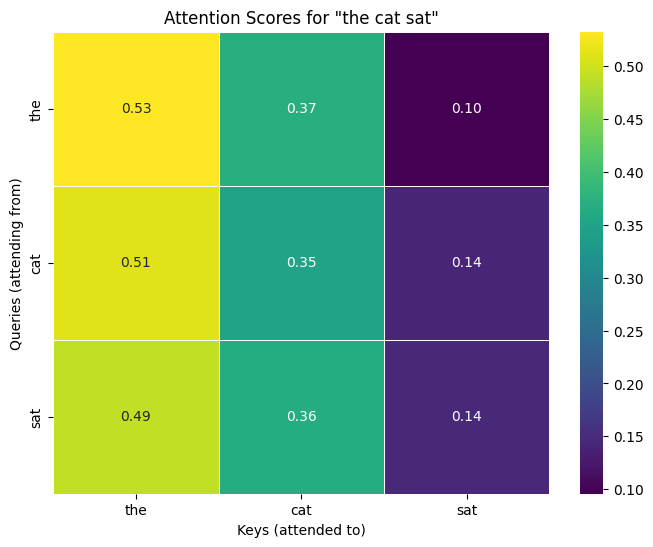

In [6]:
plt.figure(figsize=(8, 6))
sns.heatmap(attention_df, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Attention Scores for "the cat sat"')
plt.xlabel('Keys (attended to)')
plt.ylabel('Queries (attending from)')
plt.show()